In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path().resolve().parents[0]
sys.path.append(str(PROJECT_ROOT))

DATA_PATH = PROJECT_ROOT / "data"

In [2]:
from src.datamodule import SignatureDataModule
from torchvision import transforms

In [3]:
train_transforms = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.Grayscale(num_output_channels=3),

        transforms.RandomRotation(5),
        transforms.RandomAffine(
            degrees=0,
            translate=(0.02, 0.02),  
            scale=(0.95, 1.05),       
            shear=2                
        ),
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),

        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5]),
    ])


val_transforms = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

test_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
])

In [4]:


dm = SignatureDataModule(
    data_dir=DATA_PATH,
    train_transformations=train_transforms,
    val_transformations=val_transforms,
    test_transformations=test_transforms,
    batch_size=32,
    num_workers=2,
    image_size=128,
    positive_ratio=0.5,
    samples_per_epoch=10000,
)

dm.setup()
train_loader = dm.train_dataloader()
val_loader = dm.val_dataloader()
test_laoder = dm.test_dataloader()

In [5]:
from src.image_quality.analyzer import ImageQualityAnalyzer

analyzer = ImageQualityAnalyzer(train_loader)

report = analyzer.run()

report["global_summary"]


100%|██████████| 312/312 [01:57<00:00,  2.67it/s]


,blur,brightness,contrast,noise,hf_energy,edge_density,label
count,19968.000000,19968.000000,19968.000000,19968.000000,19968.000000,19968.000000,19968.000000
mean,6178.011658,217.065210,61.221317,20.628361,0.359415,0.116973,0.492388
std,4773.460592,11.449909,14.036232,6.554742,0.076304,0.028528,0.499955
min,114.695291,166.135498,15.711931,4.118463,0.108436,0.036011,0.000000
25%,2554.097028,209.362976,51.165999,15.462904,0.300802,0.094910,0.000000
50%,4626.747811,218.152039,61.803552,19.592264,0.357420,0.115540,0.000000
75%,8660.731125,225.687576,72.067536,25.480686,0.416281,0.137573,1.000000
max,29741.209962,242.324707,96.868846,43.949463,0.580169,0.218140,1.000000


In [6]:
report["classwise_summary"]

,blur,brightness,contrast,noise,hf_energy,edge_density
label,,,,,,
0,6698.489233,216.981278,61.302482,21.114073,0.369498,0.118115
1,5641.441204,217.151737,61.137641,20.127631,0.349021,0.115795


In [7]:
report["thresholds"]

{'blur': {'low': 1214.749490943551, 'high': 15767.362060192218},
 'brightness': {'low': 197.0422821044922, 'high': 234.0540588378906},
 'contrast': {'low': 37.338562260179856, 'high': 82.89361757240162},
 'noise': {'low': 11.44716444015503, 'high': 32.293212890625},
 'hf_energy': {'low': 0.24393421583379593, 'high': 0.4874541804203151},
 'edge_density': {'low': 0.0728759765625, 'high': 0.16485595703125}}

In [8]:
report["image_table"]

,blur,brightness,contrast,noise,hf_energy,edge_density,label
0,2582.736004,226.831482,50.405479,14.241187,0.339301,0.099548,0
1,1269.094835,223.154419,44.688957,12.478086,0.228216,0.129211,0
2,4053.336178,237.274292,35.427305,17.868761,0.406444,0.070801,0
3,2948.512687,186.090027,73.210003,18.030956,0.266633,0.187622,0
4,4325.934394,214.022278,69.891797,17.441216,0.369413,0.095093,1
...,...,...,...,...,...,...,...
19963,18109.708551,213.625793,75.062867,31.869715,0.479757,0.101990,0
19964,1301.912226,218.995300,49.377558,12.964469,0.212052,0.143250,0
19965,7336.095555,217.630615,56.286611,22.946589,0.403328,0.146057,0
19966,7985.763794,212.976562,62.995293,26.029451,0.392405,0.159241,0


In [9]:
from src.image_quality.plots import metric_histogram, classwise_boxplot

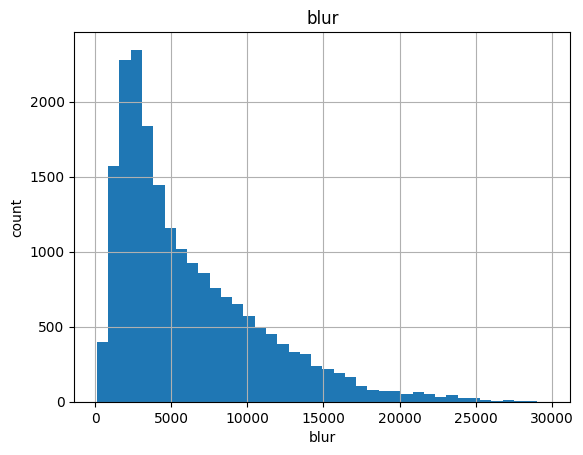

In [10]:
metric_histogram(df=report["image_table"],metric="blur")

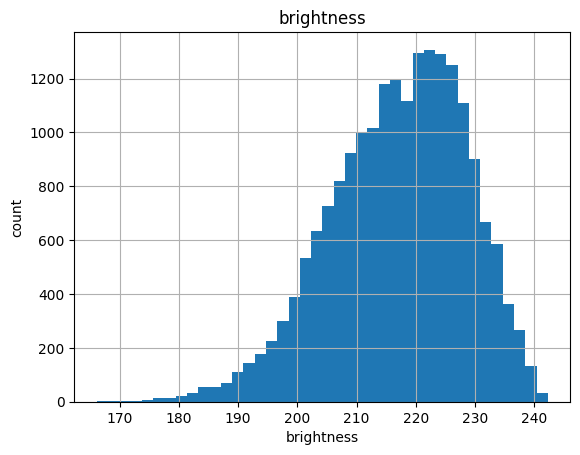

In [ ]:
metric_histogram(df=report["image_table"],metric="brightness")

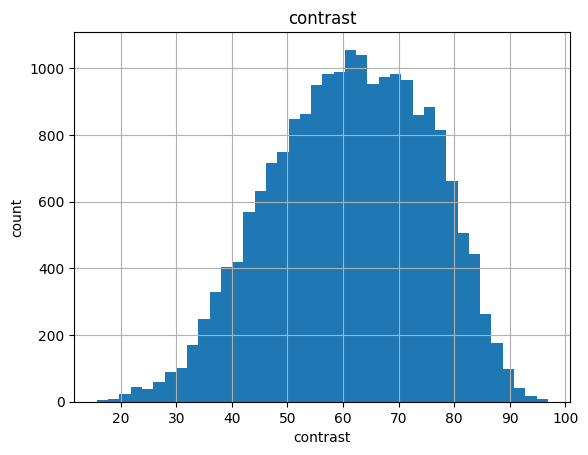

In [13]:
metric_histogram(df=report["image_table"],metric="contrast")

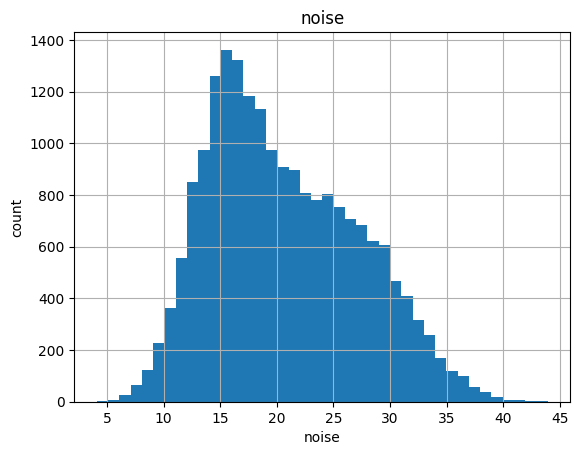

In [14]:
metric_histogram(df=report["image_table"],metric="noise")

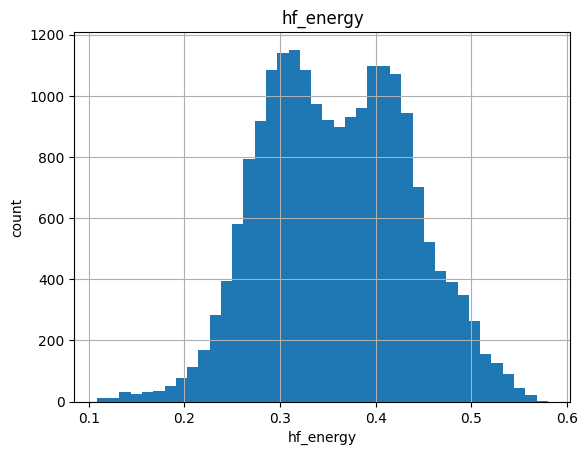

In [15]:
metric_histogram(df=report["image_table"],metric="hf_energy")

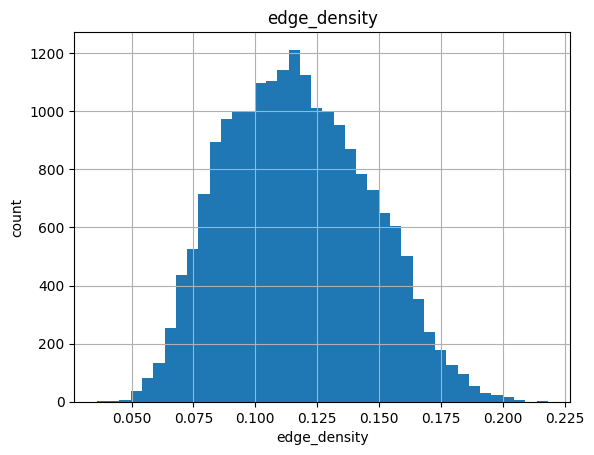

In [16]:
metric_histogram(df=report["image_table"],metric="edge_density")

<Figure size 640x480 with 0 Axes>

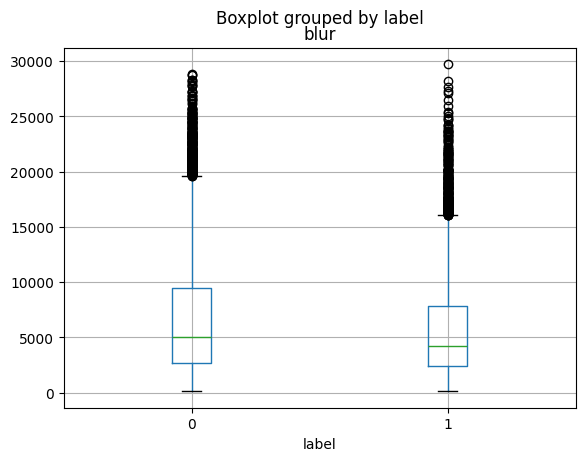

In [17]:
classwise_boxplot(df=report["image_table"],metric="blur")

<Figure size 640x480 with 0 Axes>

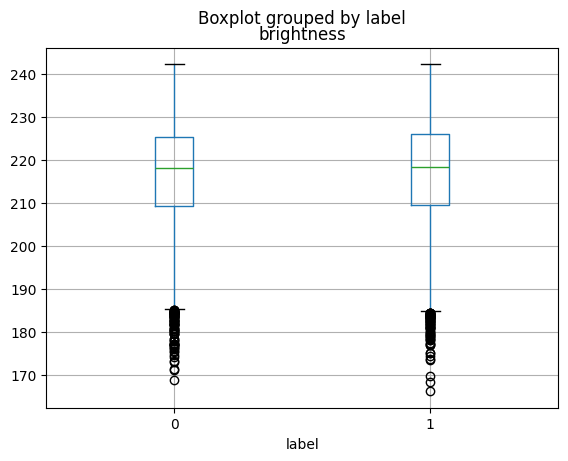

In [18]:
classwise_boxplot(df=report["image_table"],metric="brightness")

<Figure size 640x480 with 0 Axes>

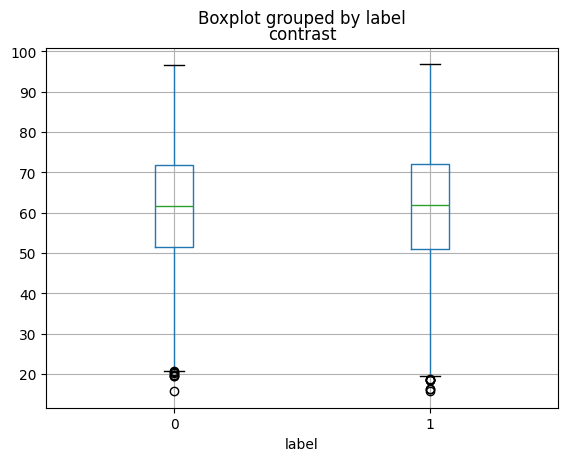

In [19]:
classwise_boxplot(df=report["image_table"],metric="contrast")

<Figure size 640x480 with 0 Axes>

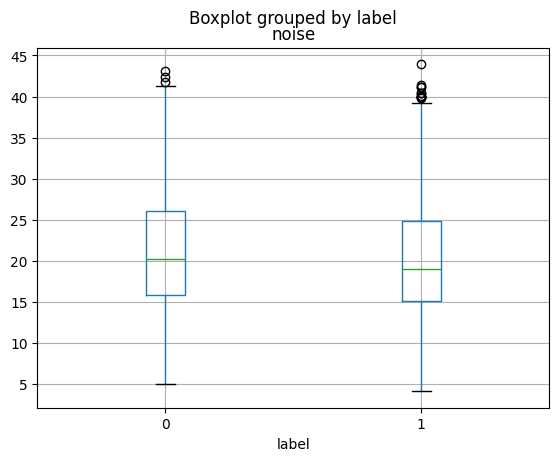

In [20]:
classwise_boxplot(df=report["image_table"],metric="noise")

<Figure size 640x480 with 0 Axes>

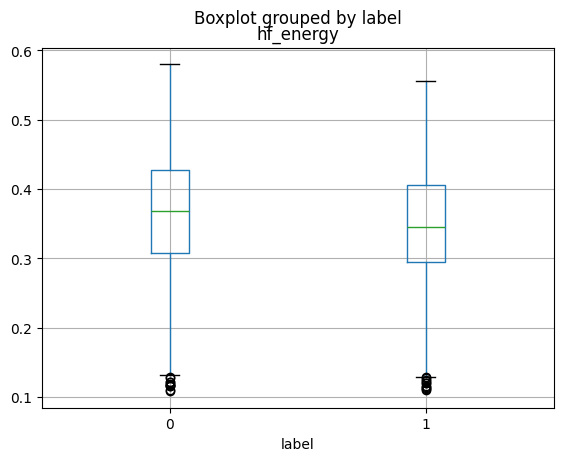

In [21]:
classwise_boxplot(df=report["image_table"],metric="hf_energy")

<Figure size 640x480 with 0 Axes>

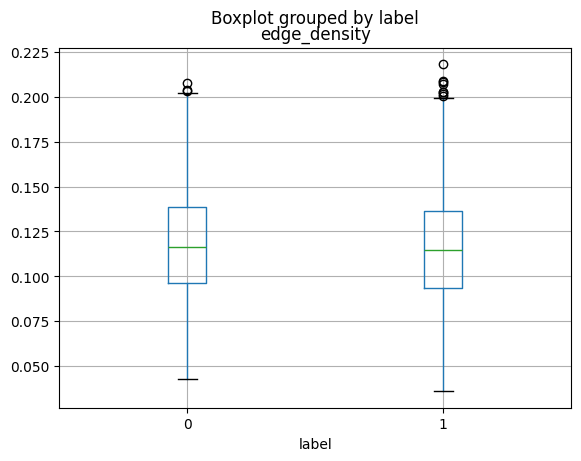

In [22]:
classwise_boxplot(df=report["image_table"],metric="edge_density")

In [23]:
analyzer = ImageQualityAnalyzer(val_loader)

report = analyzer.run()

report["global_summary"]

100%|██████████| 79/79 [00:42<00:00,  1.86it/s]


,blur,brightness,contrast,noise,hf_energy,edge_density,label
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,7422.910819,228.698307,46.979715,21.866033,0.417578,0.099651,0.498000
std,4395.255159,7.599156,10.853998,5.208148,0.059322,0.027244,0.500046
min,1138.936233,192.274963,19.282556,9.672597,0.269295,0.042480,0.000000
25%,4058.816674,225.034119,39.839036,18.221781,0.375254,0.077377,0.000000
50%,6418.127321,229.508850,47.084913,21.486263,0.405599,0.096741,0.000000
75%,9909.796866,233.905945,54.116265,25.889530,0.457343,0.119324,1.000000
max,25545.413556,242.562012,77.279464,38.284824,0.589108,0.196960,1.000000


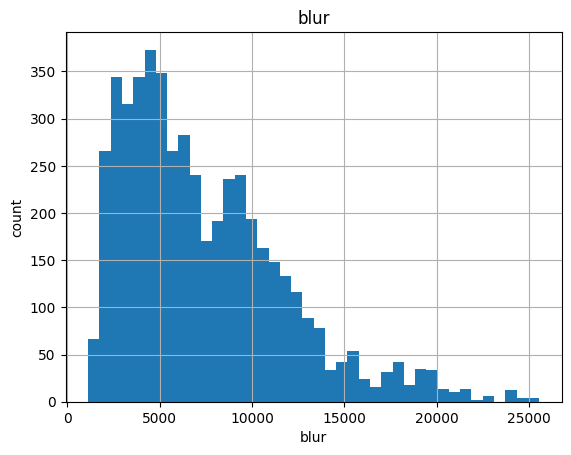

<Figure size 640x480 with 0 Axes>

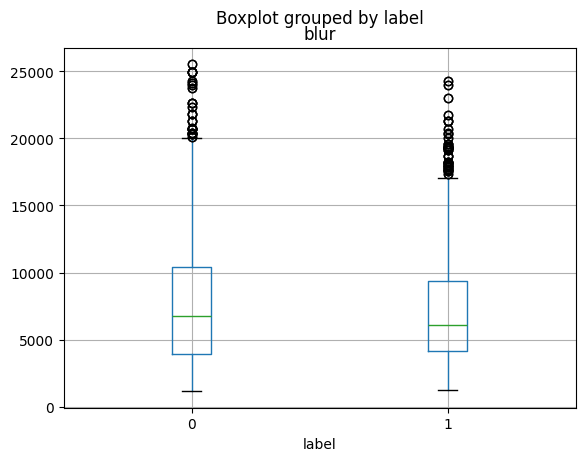

In [24]:
metric_histogram(df=report["image_table"],metric="blur")
classwise_boxplot(df=report["image_table"],metric="blur")

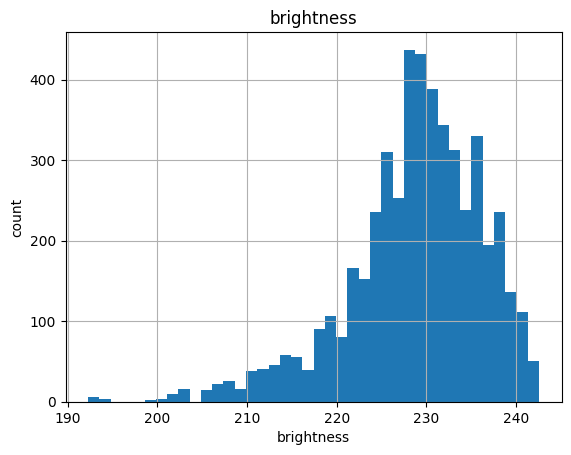

<Figure size 640x480 with 0 Axes>

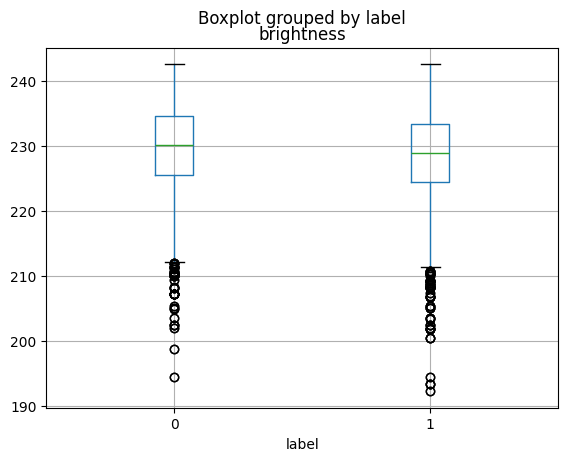

In [25]:
metric_histogram(df=report["image_table"],metric="brightness")
classwise_boxplot(df=report["image_table"],metric="brightness")

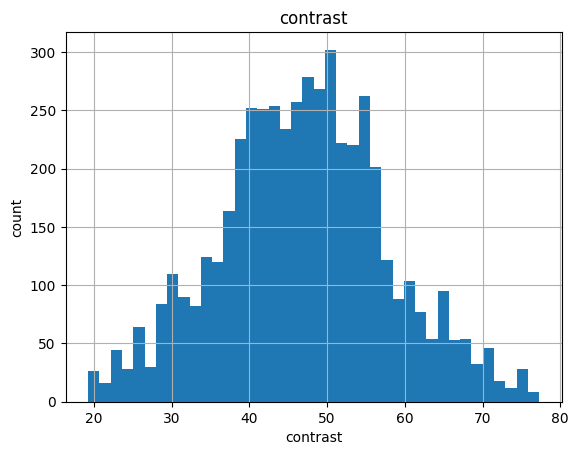

<Figure size 640x480 with 0 Axes>

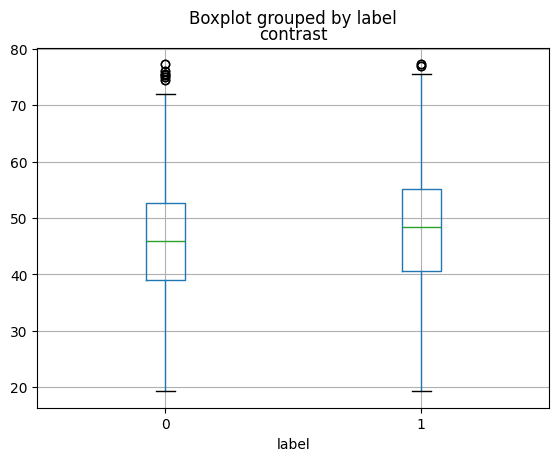

In [26]:
metric_histogram(df=report["image_table"],metric="contrast")
classwise_boxplot(df=report["image_table"],metric="contrast")

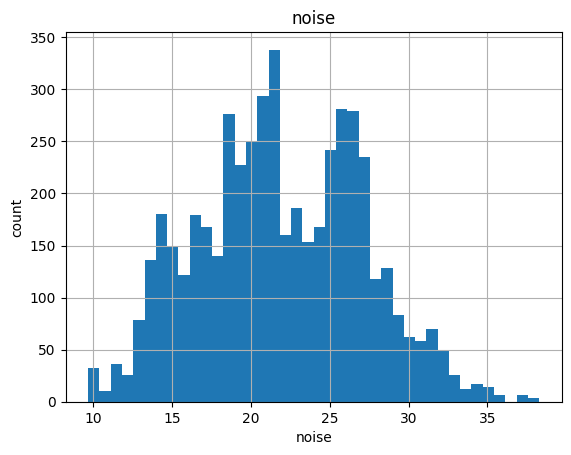

<Figure size 640x480 with 0 Axes>

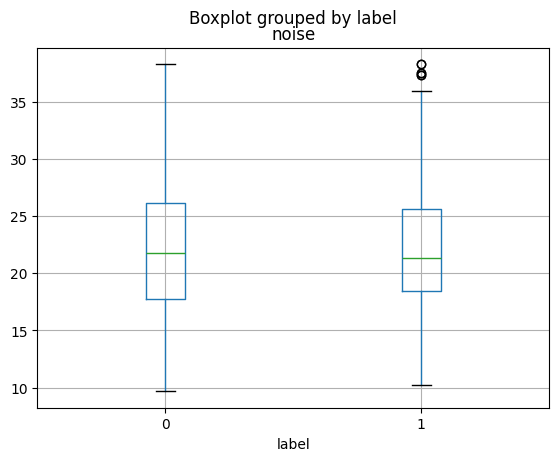

In [27]:
metric_histogram(df=report["image_table"],metric="noise")
classwise_boxplot(df=report["image_table"],metric="noise")

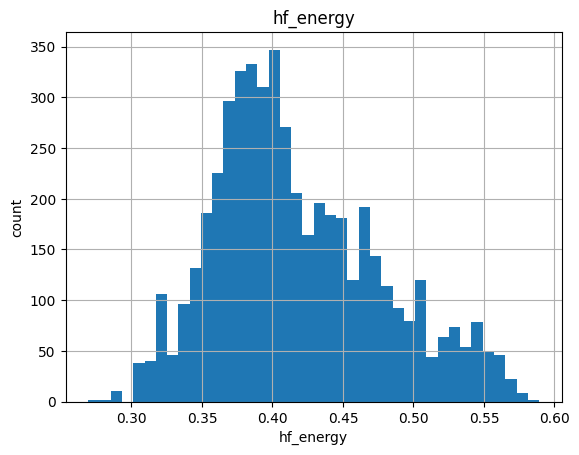

<Figure size 640x480 with 0 Axes>

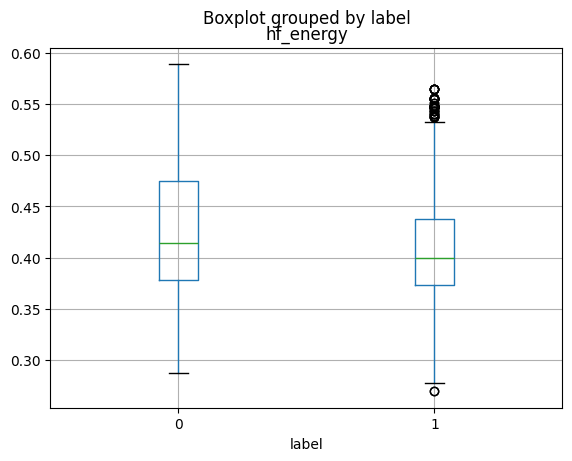

In [28]:
metric_histogram(df=report["image_table"],metric="hf_energy")
classwise_boxplot(df=report["image_table"],metric="hf_energy")

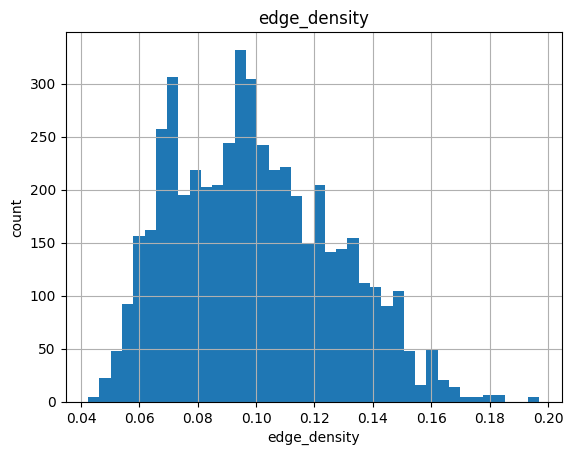

<Figure size 640x480 with 0 Axes>

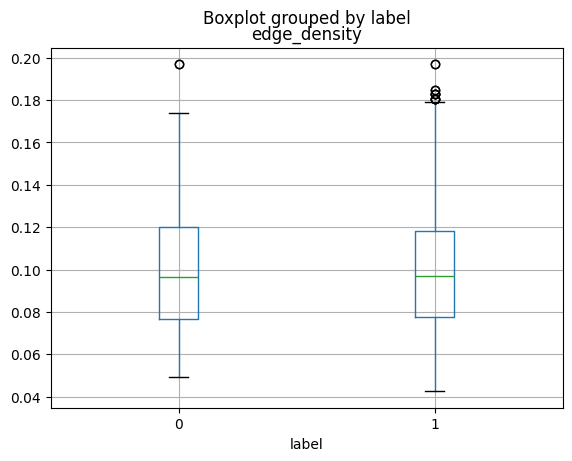

In [29]:
metric_histogram(df=report["image_table"],metric="edge_density")
classwise_boxplot(df=report["image_table"],metric="edge_density")

In [31]:
analyzer = ImageQualityAnalyzer(test_laoder)

report = analyzer.run()

report["global_summary"]

100%|██████████| 313/313 [00:22<00:00, 14.01it/s]


,blur,brightness,contrast,noise,hf_energy,edge_density,label
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,1011.494909,241.849543,23.763825,9.642098,0.290729,0.091580,0.498700
std,476.695856,4.535932,7.187286,2.350942,0.037562,0.025760,0.500011
min,284.734058,224.802124,9.641278,4.832074,0.194420,0.041870,0.000000
25%,687.698780,239.521667,18.816651,7.852853,0.261219,0.070862,0.000000
50%,942.162442,242.395020,22.808188,9.318731,0.293565,0.086731,0.000000
75%,1187.809869,245.126038,28.178472,11.301495,0.321389,0.110168,1.000000
max,3752.437414,248.781006,50.356551,20.598757,0.396764,0.163635,1.000000
